# Survey Analysis
**Ana Maria Rull Orti | IE University | April 2026**


# STEP 1: IMPORTS

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# ── SPORTS THEME ─────────────────────────────────────────────────────────────
NAVY      = '#0D1B2A'
BLUE      = '#1B4F8A'
LIGHTBLUE = '#4A90D9'
ORANGE    = '#E8892B'
GREEN     = '#2E7D52'
LIGHTGRAY = '#F0F4F8'
WHITE     = '#FFFFFF'
RED       = '#C0392B'
MIDGRAY   = '#7F8C8D'

matplotlib.rcParams.update({
    'font.family':        'DejaVu Sans',
    'axes.facecolor':     LIGHTGRAY,
    'figure.facecolor':   WHITE,
    'axes.edgecolor':     NAVY,
    'axes.labelcolor':    NAVY,
    'xtick.color':        NAVY,
    'ytick.color':        NAVY,
    'text.color':         NAVY,
    'axes.titleweight':   'bold',
    'axes.titlesize':     13,
    'axes.labelsize':     11,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.color':         WHITE,
    'grid.linewidth':     1.0,
    'figure.dpi':         150,
})

def style_bar(ax, bars, values, fmt='{:.0f}'):
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                fmt.format(val), ha='center', va='bottom',
                fontsize=10, fontweight='bold', color=NAVY)

def sport_title(ax, text):
    ax.set_title(text, pad=14, color=NAVY, loc='left')


# STEP 2: LOAD AND CLEAN DATA

In [2]:
file_path = '/content/User Behavior and Motivation in Sports Tracking Apps - TFG (respuestas).xlsx'
df = pd.read_excel(file_path)
print(f'Responses loaded: {len(df)}')

nat_map = {
    'spanish': 'Spanish', 'spain': 'Spanish', 'espanola': 'Spanish',
    'soanish': 'Spanish', 'spainsh': 'Spanish', 'spanish/spaniard': 'Spanish',
    'french': 'French',   'france': 'French',
    'italian': 'Italian', 'italy': 'Italian',
    'mexican': 'Mexican', 'brasil': 'Brazilian', 'colombian': 'Colombian',
    'german': 'German',   'british': 'British',  'danish': 'Danish'
}
df['Nationality_clean'] = (df['What is your Nationality?']
                           .dropna().str.strip().str.lower()
                           .map(nat_map).fillna('Other'))

# ── FILTER: split users vs non-users ────────────────────────
users     = df[df['Do you use sports or fitness tracking apps?'] == 'Yes'].copy()
non_users = df[df['Do you use sports or fitness tracking apps?'] == 'No'].copy()
print(f'App users: {len(users)}  |  Non-users: {len(non_users)}')

COL = {
    'age':         'What is your age?',
    'gender':      'What is your gender?',
    'app_use':     'Do you use sports or fitness tracking apps?',
    'engagement':  'To what extent do you use any sport apps? (Strava, Nike Run Club, Apple fitness, Garmin...)',
    'performance': 'I use fitness apps to improve my performance.  ',
    'enjoy':       'I enjoy using fitness apps. ',
    'rewards':     'I am motivated by rewards (badges, achievements, discounts).  ',
    'competition': 'I am motivated by competition or comparison with others. ',
    'sharing':     'I am motivated by sharing my results with others.',
    'regularity':  'Fitness apps help me exercise more regularly.  ',
    'stats':       'I check my stats after workouts.  ',
    'goal_ach':    'I achieve my fitness goals more effectively when using a tracking app',
    'pa_increase': 'My physical activity has increased since I started using fitness apps. ',
    'social_vs':   'Social features motivate me more than data tracking.  ',
    'pressure':    'I feel pressured to meet app goals.  ',
    'guilt':       'I feel bad if I do not track my activity',
    'comparison':  'Comparing myself with others negatively affects my motivation or self-esteem. ',
    'numbers':     'Focusing too much on numbers reduces my enjoyment of exercise.  ',
    'satisfaction':'Overall, I am satisfied with fitness apps.',
    'nu_interest': 'I am not interested in fitness apps.',
    'nu_complex':  'I find fitness apps too complicated to use.',
    'nu_privacy':  ' I have concerns about privacy and data sharing.',
    'nu_help':     'Fitness apps could help me exercise more regularly.',
    'nu_future':   'I would consider using a fitness app in the future.',
}

# ── COMPOSITES ───────────────────────────────────────────────
# H1: Data Feedback Composite (Q15 + Q21)
users['H1_composite'] = users[[COL['performance'], COL['stats']]].mean(axis=1)

# H2: Social Motivation Composite (Q17 + Q18 + Q19)
users['H2_composite'] = users[[COL['rewards'], COL['competition'], COL['sharing']]].mean(axis=1)

# H3: Clean Numerical Reliance Composite (Q25 + Q26 only — Q28 is now a DV)
users['H3_composite'] = users[[COL['pressure'], COL['guilt']]].mean(axis=1)

print(f'H1 composite:  M = {users["H1_composite"].mean():.2f}, SD = {users["H1_composite"].std():.2f}')
print(f'H2 composite:  M = {users["H2_composite"].mean():.2f}, SD = {users["H2_composite"].std():.2f}')
print(f'H3 composite:  M = {users["H3_composite"].mean():.2f}, SD = {users["H3_composite"].std():.2f}')

# ── H1 INTER-ITEM RELIABILITY ────────────────────────────────
r_h1, p_h1 = stats.pearsonr(
    users[COL['performance']].dropna(),
    users[COL['stats']].dropna()
)
print(f'\nH1 inter-item r (Q15 x Q21): {r_h1:.3f}, p = {p_h1:.3f}')
print(f'H1 Spearman-Brown coefficient: {(2*r_h1)/(1+r_h1):.3f}')


Responses loaded: 101
App users: 52  |  Non-users: 49
H1 composite:  M = 5.92, SD = 0.96
H2 composite:  M = 5.52, SD = 1.36
H3 composite:  M = 4.56, SD = 1.37

H1 inter-item r (Q15 x Q21): 0.210, p = 0.134
H1 Spearman-Brown coefficient: 0.348


# STEP 3: SAMPLE DESCRIPTION (Figures 1–4)

Descriptive statistics for the full sample (n = 101)

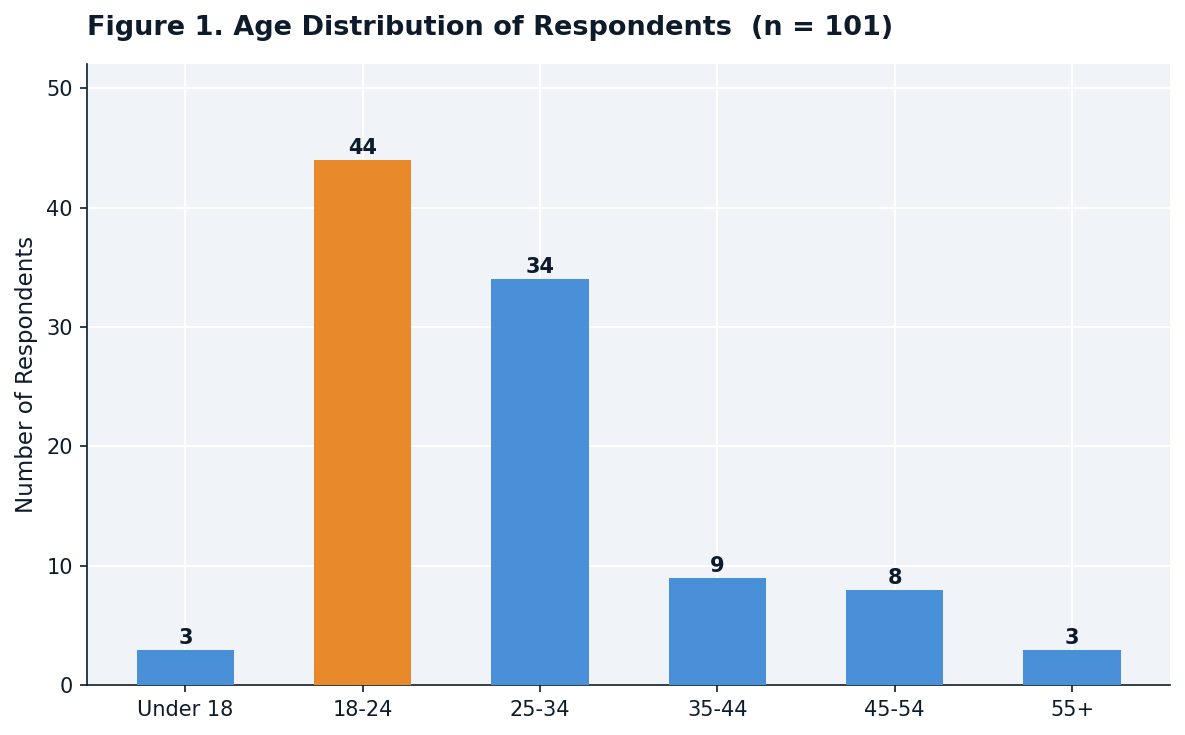

Figure 1 saved.


In [3]:
# Figure 1: Age Distribution
fig, ax = plt.subplots(figsize=(8, 5))
age_order  = ['Under 18', '18-24', '25-34', '35-44', '45-54', '55+']
age_counts = df[COL['age']].value_counts().reindex(age_order)
bar_colors = [ORANGE if v == age_counts.max() else LIGHTBLUE for v in age_counts.values]
bars = ax.bar(age_order, age_counts.values, color=bar_colors, width=0.55, zorder=3)
style_bar(ax, bars, age_counts.values)
ax.set_ylabel('Number of Respondents')
ax.set_ylim(0, age_counts.max() + 8)
sport_title(ax, 'Figure 1. Age Distribution of Respondents  (n = 101)')
plt.tight_layout()
plt.savefig('Figure_1_Age_Distribution.png', bbox_inches='tight')
plt.show()
print('Figure 1 saved.')


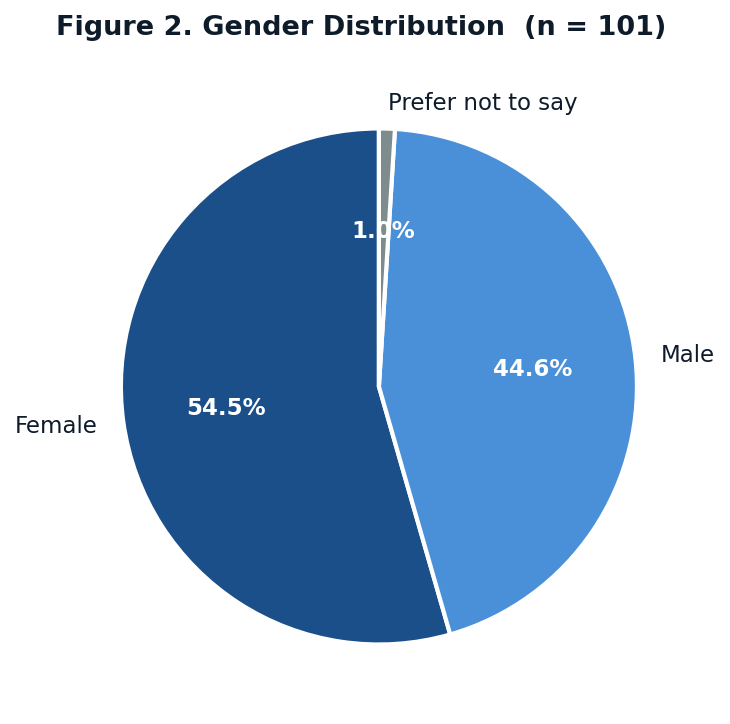

Figure 2 saved.


In [4]:
# Figure 2: Gender Distribution
fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor(WHITE)
ax.set_facecolor(WHITE)
gender_counts = df[COL['gender']].value_counts()
wedges, texts, autotexts = ax.pie(
    gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
    colors=[BLUE, LIGHTBLUE, MIDGRAY], startangle=90,
    wedgeprops={'edgecolor': WHITE, 'linewidth': 2},
    textprops={'fontsize': 11, 'color': NAVY}
)
for at in autotexts:
    at.set_fontweight('bold')
    at.set_color(WHITE)
sport_title(ax, 'Figure 2. Gender Distribution  (n = 101)')
plt.tight_layout()
plt.savefig('Figure_2_Gender_Distribution.png', bbox_inches='tight')
plt.show()
print('Figure 2 saved.')


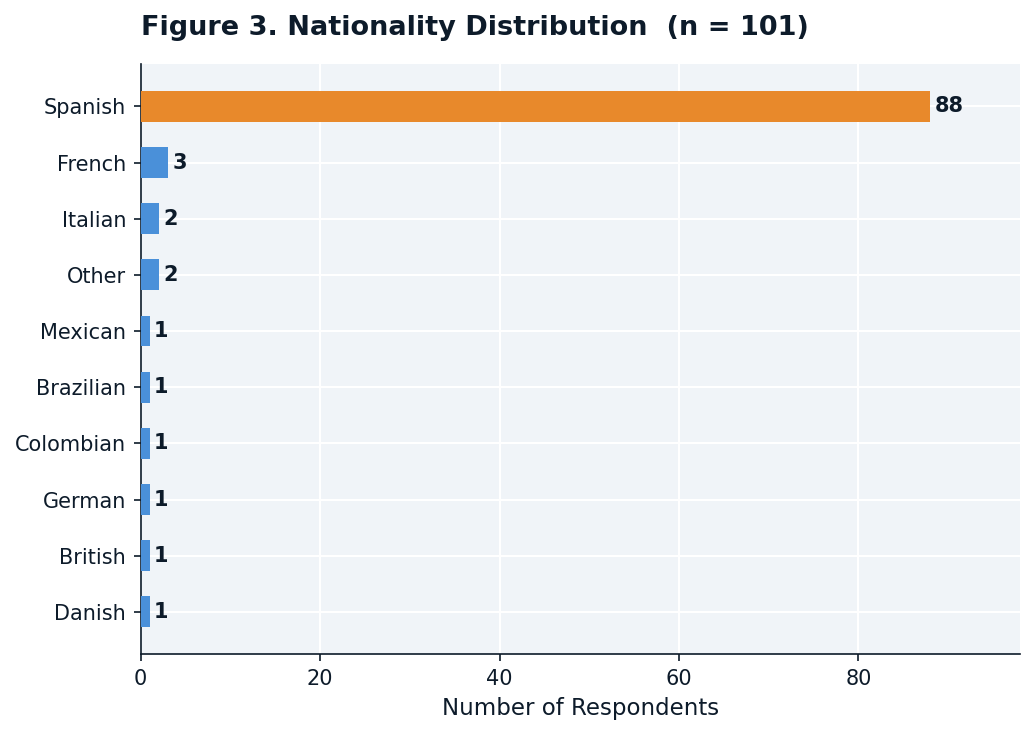

Figure 3 saved.


In [5]:
# Figure 3: Nationality Distribution
fig, ax = plt.subplots(figsize=(7, 5))
nat_counts = df['Nationality_clean'].value_counts()
bar_colors_n = [ORANGE if i == 0 else LIGHTBLUE for i in range(len(nat_counts))]
bars = ax.barh(nat_counts.index[::-1], nat_counts.values[::-1],
               color=bar_colors_n[::-1], height=0.55, zorder=3)
for bar, val in zip(bars, nat_counts.values[::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10, fontweight='bold', color=NAVY)
ax.set_xlabel('Number of Respondents')
ax.set_xlim(0, nat_counts.max() + 10)
sport_title(ax, 'Figure 3. Nationality Distribution  (n = 101)')
plt.tight_layout()
plt.savefig('Figure_3_Nationality_Distribution.png', bbox_inches='tight')
plt.show()
print('Figure 3 saved.')


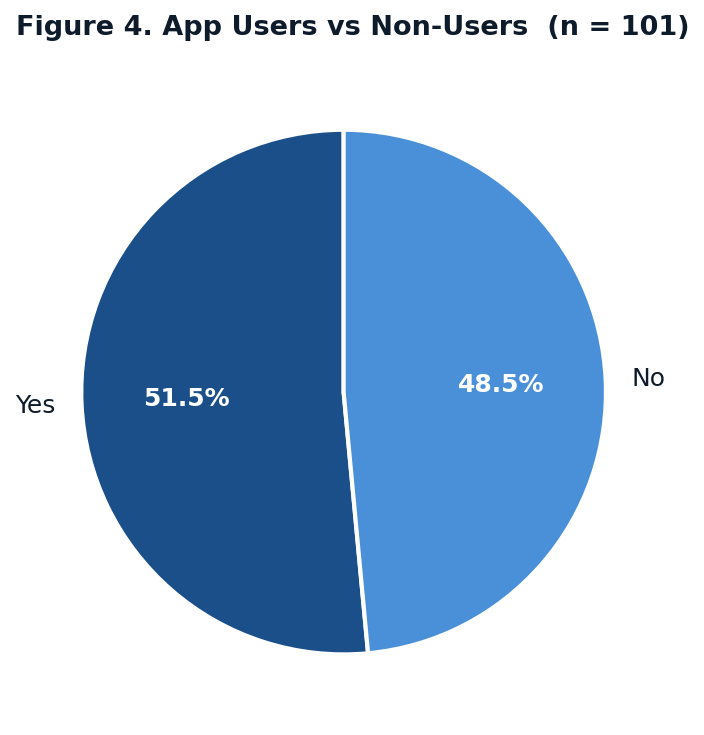

Figure 4 saved.


In [6]:
# Figure 4: Users vs Non-Users
fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor(WHITE)
ax.set_facecolor(WHITE)
use_counts = df[COL['app_use']].value_counts()
wedges, texts, autotexts = ax.pie(
    use_counts.values, labels=use_counts.index, autopct='%1.1f%%',
    colors=[BLUE, LIGHTBLUE], startangle=90,
    wedgeprops={'edgecolor': WHITE, 'linewidth': 2},
    textprops={'fontsize': 12, 'color': NAVY}
)
for at in autotexts:
    at.set_fontweight('bold')
    at.set_color(WHITE)
sport_title(ax, 'Figure 4. App Users vs Non-Users  (n = 101)')
plt.tight_layout()
plt.savefig('Figure_4_Users_NonUsers.png', bbox_inches='tight')
plt.show()
print('Figure 4 saved.')


# STEP 4: DESCRIPTIVE STATISTICS (Table 2 + Figure 5)

In [7]:
# Print Table 2 with skewness and kurtosis
desc_cols = {
    'Q15 Improve performance [H1 IV]':           COL['performance'],
    'Q21 Check stats after workouts [H1 IV]':    COL['stats'],
    'H1 Data Feedback Composite':                'H1_composite',
    'Q22 Goal achievement [H1 DV]':              COL['goal_ach'],
    'Q23 PA increase [H1 DV]':                   COL['pa_increase'],
    'Q20 Exercise more regularly [H1 DV]':       COL['regularity'],
    'Q17 Rewards motivation [H2 IV]':            COL['rewards'],
    'Q18 Competition motivation [H2 IV]':        COL['competition'],
    'Q19 Sharing motivation [H2 IV]':            COL['sharing'],
    'H2 Social Motivation Composite':            'H2_composite',
    'Q13 App usage frequency [H2 DV]':           COL['engagement'],
    'Q24 Social features > data [H2 direct]':    COL['social_vs'],
    'Q25 Pressure to meet goals [H3 IV]':        COL['pressure'],
    'Q26 Feel bad if not tracked [H3 IV]':       COL['guilt'],
    'H3 Numerical Reliance Composite (Q25+Q26)': 'H3_composite',
    'Q28 Numbers reduce enjoyment [H3 DV]':      COL['numbers'],
    'Q16 Enjoy fitness apps [H3 DV]':            COL['enjoy'],
    'Q27 Comparison anxiety [H3 DV]':            COL['comparison'],
    'Q29 Overall satisfaction':                  COL['satisfaction'],
}

print('=' * 85)
print('TABLE 2 — DESCRIPTIVE STATISTICS (App Users, n = 52)')
print('=' * 85)
print(f'{"Item":<45} {"M":>5} {"SD":>5} {"Min":>5} {"Max":>5} {"Skew":>6} {"Kurt":>6} {"n":>4}')
print('-' * 85)
for label, col in desc_cols.items():
    s = users[col].dropna()
    print(f'{label:<45} {s.mean():>5.2f} {s.std():>5.2f} {s.min():>5.2f} {s.max():>5.2f} {s.skew():>6.2f} {s.kurtosis():>6.2f} {len(s):>4}')

# ── COMPOSITE RELIABILITY ─────────────────────────────────────
print('\n' + '=' * 60)
print('COMPOSITE RELIABILITY')
print('=' * 60)

# H1 inter-item reliability
r_h1, p_h1 = stats.pearsonr(
    users[COL['performance']].dropna(),
    users[COL['stats']].dropna()
)
print(f'\nH1 inter-item r (Q15 x Q21): r = {r_h1:.3f}, p = {p_h1:.3f}')
print(f'H1 Spearman-Brown: {(2*r_h1)/(1+r_h1):.3f}')

# H2 mean inter-item r (3 pairs)
pairs_h2 = [
    (COL['rewards'],     COL['competition']),
    (COL['rewards'],     COL['sharing']),
    (COL['competition'], COL['sharing']),
]
rs_h2 = [stats.pearsonr(users[a].dropna(), users[b].dropna())[0] for a, b in pairs_h2]
print(f'\nH2 inter-item r (Q17 x Q18): {rs_h2[0]:.3f}')
print(f'H2 inter-item r (Q17 x Q19): {rs_h2[1]:.3f}')
print(f'H2 inter-item r (Q18 x Q19): {rs_h2[2]:.3f}')
print(f'H2 mean inter-item r: {sum(rs_h2)/len(rs_h2):.3f}')

# H3 inter-item reliability
r_h3, p_h3 = stats.pearsonr(
    users[COL['pressure']].dropna(),
    users[COL['guilt']].dropna()
)
print(f'\nH3 inter-item r (Q25 x Q26): r = {r_h3:.3f}, p = {p_h3:.3f}')
print(f'H3 Spearman-Brown: {(2*r_h3)/(1+r_h3):.3f}')


TABLE 2 — DESCRIPTIVE STATISTICS (App Users, n = 52)
Item                                              M    SD   Min   Max   Skew   Kurt    n
-------------------------------------------------------------------------------------
Q15 Improve performance [H1 IV]                5.46  1.57  1.00  7.00  -1.23   1.34   52
Q21 Check stats after workouts [H1 IV]         6.38  0.82  4.00  7.00  -1.28   1.08   52
H1 Data Feedback Composite                     5.92  0.96  3.50  7.00  -0.80  -0.06   52
Q22 Goal achievement [H1 DV]                   5.98  1.43  1.00  7.00  -1.71   2.63   52
Q23 PA increase [H1 DV]                        5.73  1.55  2.00  7.00  -1.18   0.45   52
Q20 Exercise more regularly [H1 DV]            5.73  1.42  1.00  7.00  -1.48   2.25   52
Q17 Rewards motivation [H2 IV]                 5.56  1.58  1.00  7.00  -1.28   1.29   52
Q18 Competition motivation [H2 IV]             5.21  1.77  1.00  7.00  -0.92  -0.23   52
Q19 Sharing motivation [H2 IV]                 5.79  1.53  1

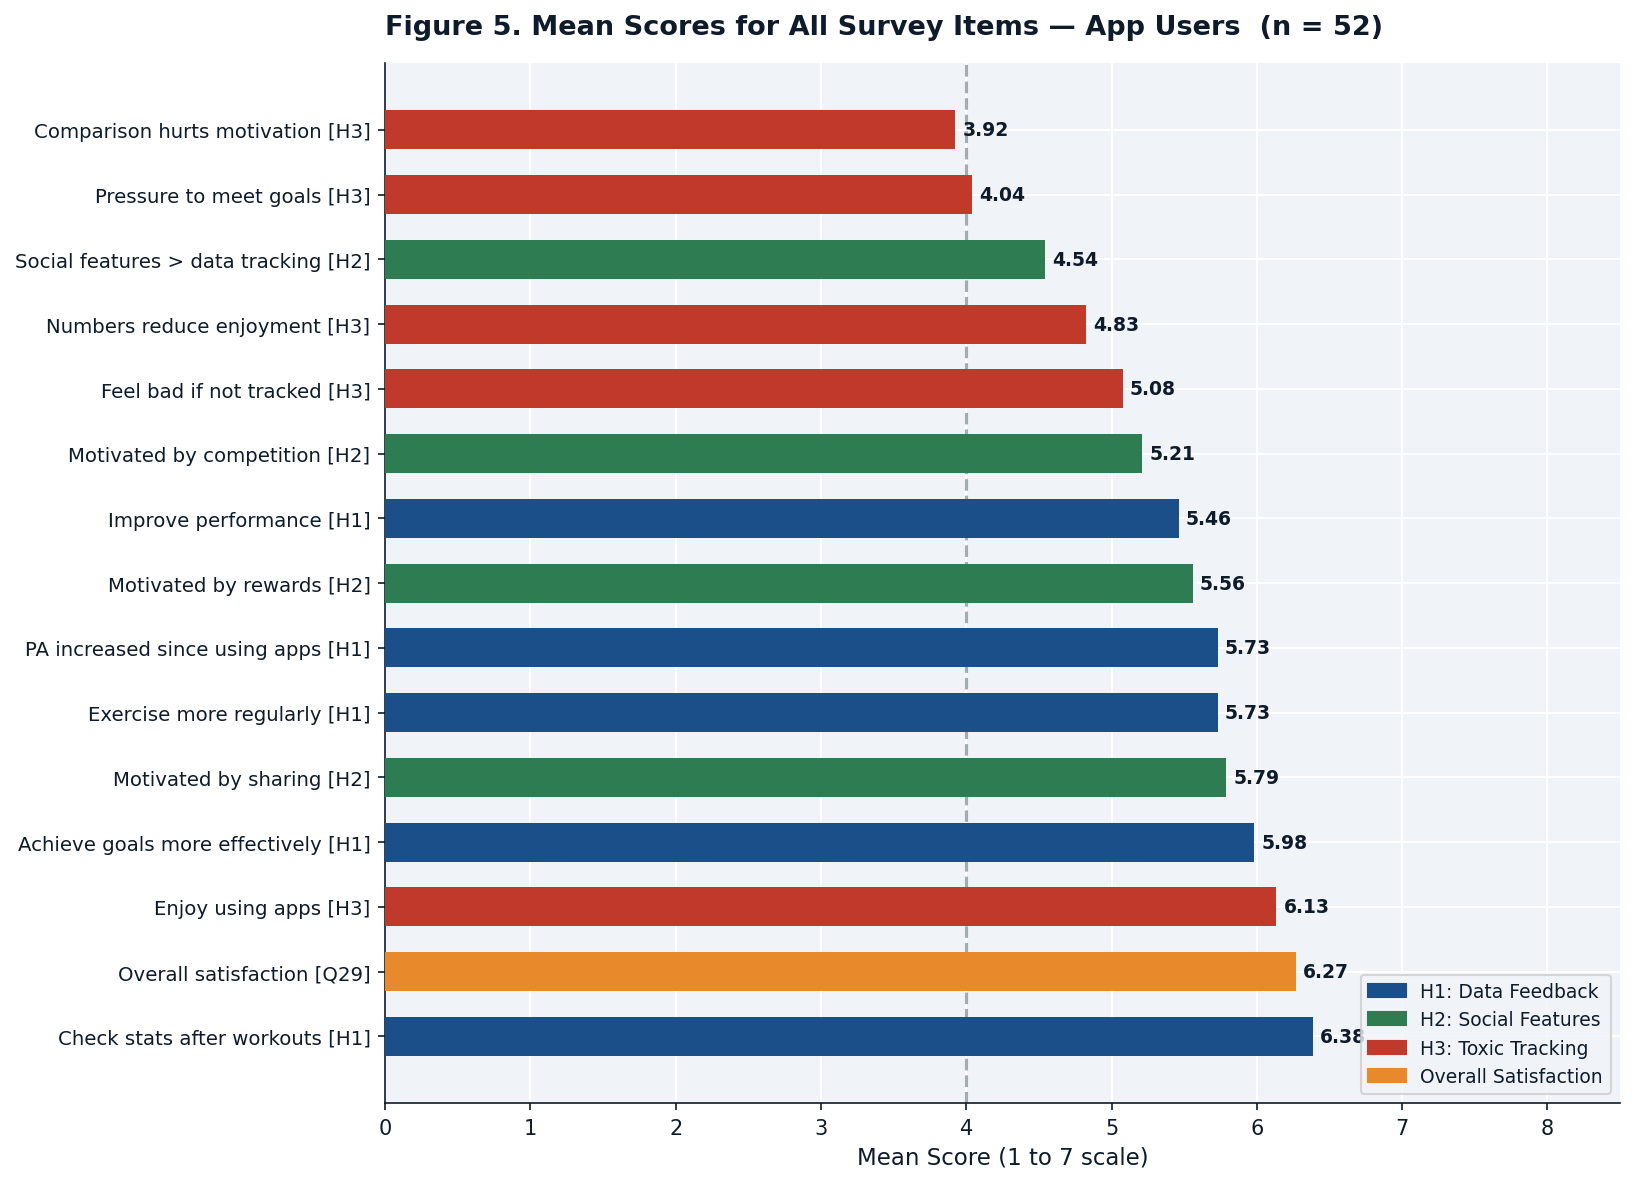

Figure 5 saved.


In [8]:
# Figure 5: Mean Scores Overview
items = {
    'Check stats after workouts [H1]':       users[COL['stats']].mean(),
    'Overall satisfaction [Q29]':            users[COL['satisfaction']].mean(),
    'Enjoy using apps [H3]':                 users[COL['enjoy']].mean(),
    'Achieve goals more effectively [H1]':   users[COL['goal_ach']].mean(),
    'Exercise more regularly [H1]':          users[COL['regularity']].mean(),
    'PA increased since using apps [H1]':    users[COL['pa_increase']].mean(),
    'Motivated by sharing [H2]':             users[COL['sharing']].mean(),
    'Motivated by rewards [H2]':             users[COL['rewards']].mean(),
    'Improve performance [H1]':              users[COL['performance']].mean(),
    'Motivated by competition [H2]':         users[COL['competition']].mean(),
    'Feel bad if not tracked [H3]':          users[COL['guilt']].mean(),
    'Numbers reduce enjoyment [H3]':         users[COL['numbers']].mean(),
    'Social features > data tracking [H2]':  users[COL['social_vs']].mean(),
    'Pressure to meet goals [H3]':           users[COL['pressure']].mean(),
    'Comparison hurts motivation [H3]':      users[COL['comparison']].mean(),
}
items = dict(sorted(items.items(), key=lambda x: x[1], reverse=True))
labels = list(items.keys())
means  = list(items.values())
h_colors = [BLUE if '[H1]' in l else GREEN if '[H2]' in l else RED if '[H3]' in l else ORANGE for l in labels]

fig, ax = plt.subplots(figsize=(11, 8))
bars = ax.barh(range(len(labels)), means, color=h_colors, height=0.6, zorder=3)
for bar, val in zip(bars, means):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9, fontweight='bold', color=NAVY)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=9.5)
ax.set_xlabel('Mean Score (1 to 7 scale)')
ax.set_xlim(0, 8.5)
ax.axvline(x=4, color=MIDGRAY, linestyle='--', alpha=0.7, linewidth=1.5)
sport_title(ax, 'Figure 5. Mean Scores for All Survey Items — App Users  (n = 52)')
legend_patches = [
    mpatches.Patch(color=BLUE,   label='H1: Data Feedback'),
    mpatches.Patch(color=GREEN,  label='H2: Social Features'),
    mpatches.Patch(color=RED,    label='H3: Toxic Tracking'),
    mpatches.Patch(color=ORANGE, label='Overall Satisfaction'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('Figure_5_Mean_Scores.png', bbox_inches='tight')
plt.show()
print('Figure 5 saved.')


# STEP 5: H1 — Data Feedback Engagement and Self-Efficacy

In [9]:
# H1 inter-item reliability and regressions
r_q15_q21, p_q15_q21 = stats.pearsonr(
    users[COL['performance']].dropna(),
    users[COL['stats']].dropna()
)
print(f'H1 inter-item r (Q15 x Q21): r = {r_q15_q21:.3f}, p = {p_q15_q21:.3f}')
print(f'Spearman-Brown coefficient: {(2*r_q15_q21)/(1+r_q15_q21):.3f}')
print()
print('H1 REGRESSIONS (H1 composite → Q22, Q23, Q20):')
for dv_label, dv_col in [
    ('Q22 Goal achievement',        COL['goal_ach']),
    ('Q23 PA increase',              COL['pa_increase']),
    ('Q20 Exercise more regularly',  COL['regularity']),
]:
    d = users[['H1_composite', dv_col]].dropna()
    r, p_r = stats.pearsonr(d['H1_composite'], d[dv_col])
    X = sm.add_constant(d['H1_composite'])
    model = sm.OLS(d[dv_col], X).fit()
    print(f'  H1 → {dv_label}: r={r:.3f}, β={model.params["H1_composite"]:.3f}, R²={model.rsquared:.3f}, F={model.fvalue:.3f}, p={model.f_pvalue:.4f}')


H1 inter-item r (Q15 x Q21): r = 0.210, p = 0.134
Spearman-Brown coefficient: 0.348

H1 REGRESSIONS (H1 composite → Q22, Q23, Q20):
  H1 → Q22 Goal achievement: r=0.570, β=0.855, R²=0.325, F=24.091, p=0.0000
  H1 → Q23 PA increase: r=0.714, β=1.155, R²=0.509, F=51.932, p=0.0000
  H1 → Q20 Exercise more regularly: r=0.665, β=0.984, R²=0.442, F=39.575, p=0.0000


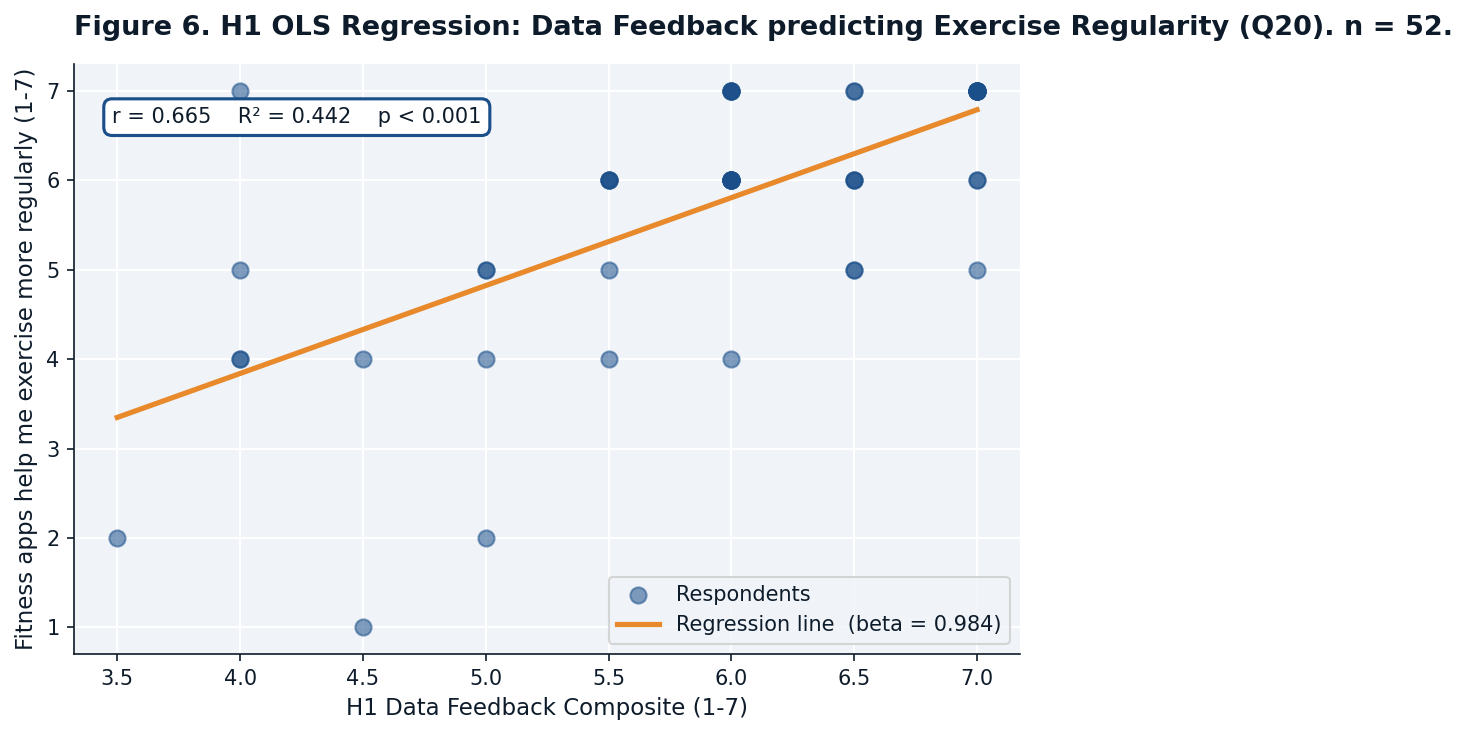

Figure 6 saved.


In [10]:
# Figure 6: H1 OLS Regression — Q20 (Exercise Regularity)
d = users[['H1_composite', COL['regularity']]].dropna()
slope, intercept, r, p, se = stats.linregress(d['H1_composite'], d[COL['regularity']])
x_line = np.linspace(d['H1_composite'].min(), d['H1_composite'].max(), 200)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(d['H1_composite'], d[COL['regularity']], color=BLUE, alpha=0.55, s=60, zorder=3, label='Respondents')
ax.plot(x_line, slope * x_line + intercept, color=ORANGE, linewidth=2.5,
        label=f'Regression line  (beta = {slope:.3f})')
ax.set_xlabel('H1 Data Feedback Composite (1-7)')
ax.set_ylabel('Fitness apps help me exercise more regularly (1-7)')
sport_title(ax, 'Figure 6. H1 OLS Regression: Data Feedback predicting Exercise Regularity (Q20). n = 52.')
ax.legend(fontsize=10)
ax.text(0.04, 0.90, f'r = {r:.3f}    R² = {r**2:.3f}    p < 0.001',
        transform=ax.transAxes, fontsize=10, color=NAVY,
        bbox=dict(boxstyle='round,pad=0.4', facecolor=WHITE, edgecolor=BLUE, linewidth=1.5))
plt.tight_layout()
plt.savefig('Figure_6_H1_Regression.png', bbox_inches='tight')
plt.show()
print('Figure 6 saved.')


# STEP 6: H2 — Social Features vs Data Tracking Motivation

In [11]:
# H2 correlations and paired t-test
print('H2 CORRELATIONS:')
for cx, cy, lbl in [
    (COL['sharing'],     COL['engagement'], 'Sharing x Engagement'),
    (COL['rewards'],     COL['engagement'], 'Rewards x Engagement'),
    (COL['competition'], COL['engagement'], 'Competition x Engagement'),
    ('H2_composite',     COL['engagement'], 'Social composite x Engagement'),
]:
    c = users[[cx, cy]].dropna()
    r, p = stats.pearsonr(c.iloc[:,0], c.iloc[:,1])
    print(f'  {lbl}: r = {r:.3f}, p = {p:.3f}')

soc = users['H2_composite'].dropna()
dat = users[COL['performance']].dropna()
t, pt = stats.ttest_rel(soc, dat[:len(soc)])
print(f'\n  Paired t-test (social vs data): t = {t:.3f}, p = {pt:.3f}')

d = users[['H2_composite', COL['engagement']]].dropna()
X = sm.add_constant(d['H2_composite'])
model = sm.OLS(d[COL['engagement']], X).fit()
print(f'  H2 OLS: β = {model.params["H2_composite"]:.3f}, R² = {model.rsquared:.3f}, F = {model.fvalue:.3f}, p = {model.f_pvalue:.4f}')


H2 CORRELATIONS:
  Sharing x Engagement: r = 0.568, p = 0.000
  Rewards x Engagement: r = 0.288, p = 0.039
  Competition x Engagement: r = 0.270, p = 0.053
  Social composite x Engagement: r = 0.440, p = 0.001

  Paired t-test (social vs data): t = 0.316, p = 0.753
  H2 OLS: β = 0.448, R² = 0.194, F = 12.036, p = 0.0011


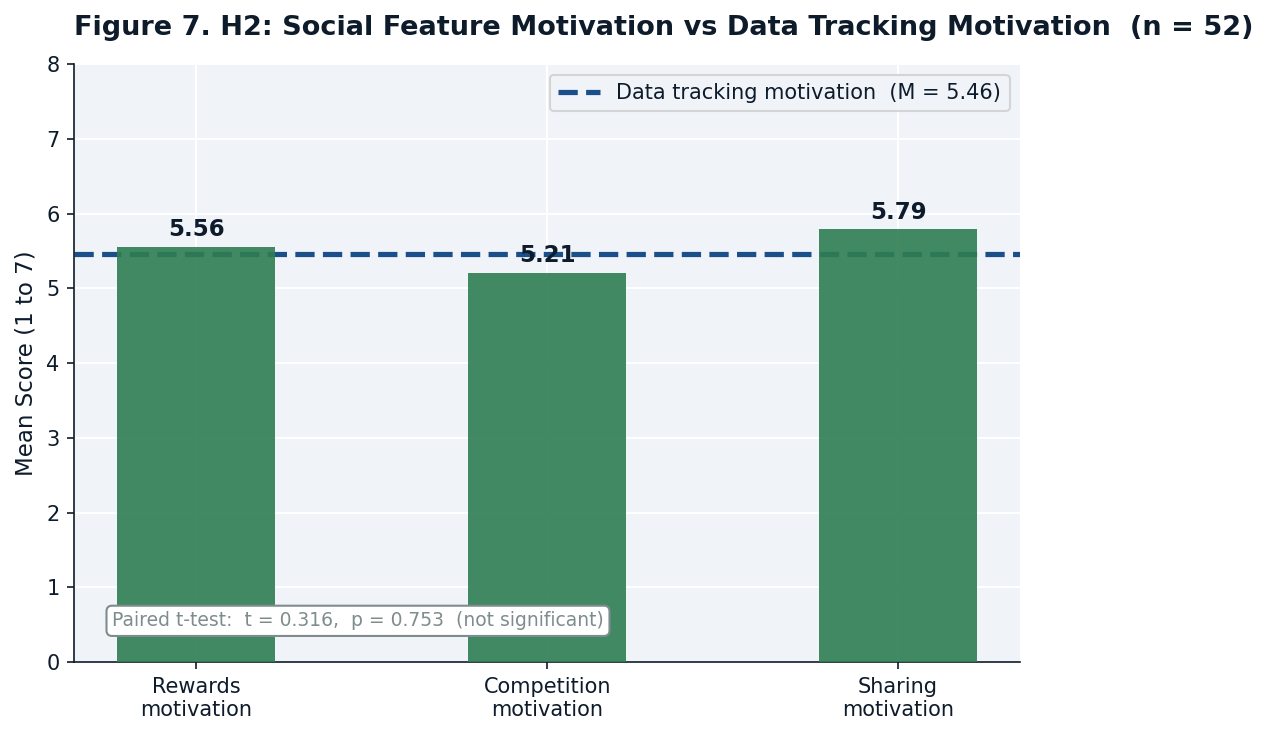

Figure 7 saved.


In [12]:
# Figure 7: Social vs Data Tracking Motivation
soc = users['H2_composite'].dropna()
dat = users[COL['performance']].dropna()
t, pt = stats.ttest_rel(soc, dat[:len(soc)])

fig, ax = plt.subplots(figsize=(7, 5))
s_means  = [users[COL['rewards']].mean(), users[COL['competition']].mean(), users[COL['sharing']].mean()]
s_labels = ['Rewards\nmotivation', 'Competition\nmotivation', 'Sharing\nmotivation']
data_mean = users[COL['performance']].mean()
bars = ax.bar(s_labels, s_means, color=GREEN, width=0.45, zorder=3, alpha=0.9)
ax.axhline(y=data_mean, color=BLUE, linewidth=2.5, linestyle='--',
           label=f'Data tracking motivation  (M = {data_mean:.2f})')
for bar, val in zip(bars, s_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.08,
            f'{val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold', color=NAVY)
ax.set_ylabel('Mean Score (1 to 7)')
ax.set_ylim(0, 8)
sport_title(ax, 'Figure 7. H2: Social Feature Motivation vs Data Tracking Motivation  (n = 52)')
ax.legend(fontsize=10)
ax.text(0.04, 0.06, f'Paired t-test:  t = {t:.3f},  p = {pt:.3f}  (not significant)',
        transform=ax.transAxes, fontsize=9, color=MIDGRAY,
        bbox=dict(boxstyle='round,pad=0.3', facecolor=WHITE, edgecolor=MIDGRAY))
plt.tight_layout()
plt.savefig('Figure_7_H2_Comparison.png', bbox_inches='tight')
plt.show()
print('Figure 7 saved.')


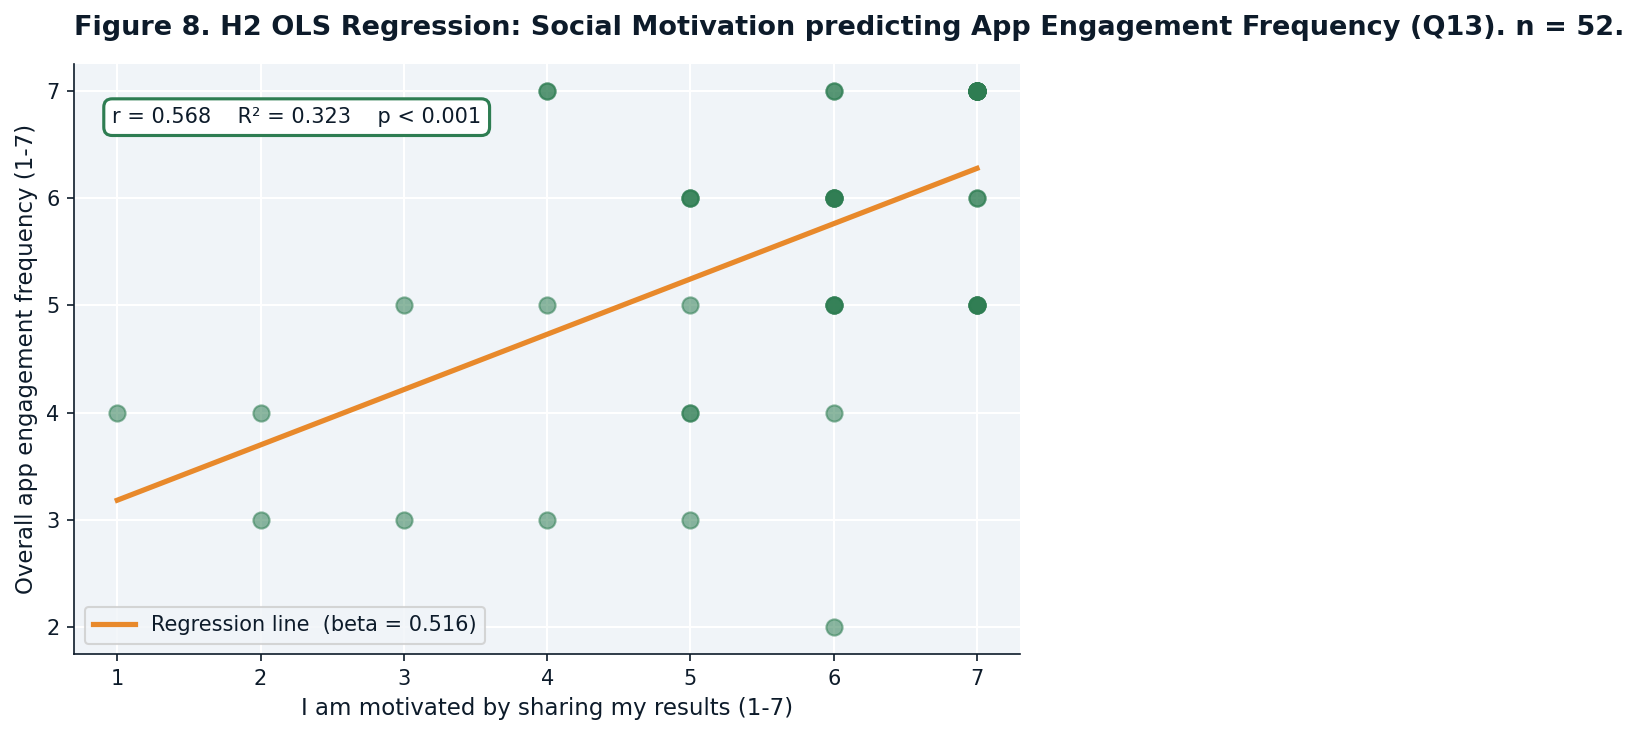

Figure 8 saved.


In [13]:
# Figure 8: H2 OLS Regression — Sharing Motivation vs Engagement
x = users[COL['sharing']].dropna().values
y = users[COL['engagement']].dropna().values
n = min(len(x), len(y))
x, y = x[:n], y[:n]
slope, intercept, r, p, se = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 200)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x, y, color=GREEN, alpha=0.55, s=60, zorder=3)
ax.plot(x_line, slope * x_line + intercept, color=ORANGE, linewidth=2.5,
        label=f'Regression line  (beta = {slope:.3f})')
ax.set_xlabel('I am motivated by sharing my results (1-7)')
ax.set_ylabel('Overall app engagement frequency (1-7)')
sport_title(ax, 'Figure 8. H2 OLS Regression: Social Motivation predicting App Engagement Frequency (Q13). n = 52.')
ax.legend(fontsize=10)
ax.text(0.04, 0.90, f'r = {r:.3f}    R² = {r**2:.3f}    p < 0.001',
        transform=ax.transAxes, fontsize=10, color=NAVY,
        bbox=dict(boxstyle='round,pad=0.4', facecolor=WHITE, edgecolor=GREEN, linewidth=1.5))
plt.tight_layout()
plt.savefig('Figure_8_H2_Regression.png', bbox_inches='tight')
plt.show()
print('Figure 8 saved.')


# STEP 7: H3 — Numerical Target Reliance and Negative Outcomes

> **Note:** H3 composite = mean(Q25, Q26) only. Q28 is treated as a separate dependent variable.

In [14]:
# H3 one-sample t-tests and correlations
print(f'H3 Clean Composite (Q25+Q26): M = {users["H3_composite"].mean():.2f}, SD = {users["H3_composite"].std():.2f}')
print()
print('ONE-SAMPLE T-TESTS vs midpoint (4):')
for label, col in [
    ('Q25 Goal pressure',      COL['pressure']),
    ('Q26 Guilt',              COL['guilt']),
    ('Q27 Comparison anxiety', COL['comparison']),
    ('Q28 Numbers hurt enjoy', COL['numbers']),
]:
    t, p = stats.ttest_1samp(users[col].dropna(), 4)
    print(f'  {label}: M = {users[col].mean():.2f}, t = {t:.3f}, p = {p:.3f}')
print()
print('H3 CORRELATIONS AND REGRESSIONS (clean composite Q25+Q26):')
for dv_label, dv_col in [
    ('Q16 Enjoyment',                COL['enjoy']),
    ('Q27 Comparison anxiety',       COL['comparison']),
    ('Q28 Numbers reduce enjoyment', COL['numbers']),
]:
    d = users[['H3_composite', dv_col]].dropna()
    r, p = stats.pearsonr(d['H3_composite'], d[dv_col])
    X = sm.add_constant(d['H3_composite'])
    model = sm.OLS(d[dv_col], X).fit()
    print(f'  H3 → {dv_label}: r={r:.3f}, β={model.params["H3_composite"]:.3f}, R²={model.rsquared:.3f}, F={model.fvalue:.3f}, p={model.f_pvalue:.4f}')


H3 Clean Composite (Q25+Q26): M = 4.56, SD = 1.37

ONE-SAMPLE T-TESTS vs midpoint (4):
  Q25 Goal pressure: M = 4.04, t = 0.182, p = 0.856
  Q26 Guilt: M = 5.08, t = 4.659, p = 0.000
  Q27 Comparison anxiety: M = 3.92, t = -0.335, p = 0.739
  Q28 Numbers hurt enjoy: M = 4.83, t = 3.252, p = 0.002

H3 CORRELATIONS AND REGRESSIONS (clean composite Q25+Q26):
  H3 → Q16 Enjoyment: r=0.379, β=0.257, R²=0.143, F=8.363, p=0.0057
  H3 → Q27 Comparison anxiety: r=0.430, β=0.519, R²=0.185, F=11.331, p=0.0015
  H3 → Q28 Numbers reduce enjoyment: r=0.523, β=0.699, R²=0.273, F=18.813, p=0.0001


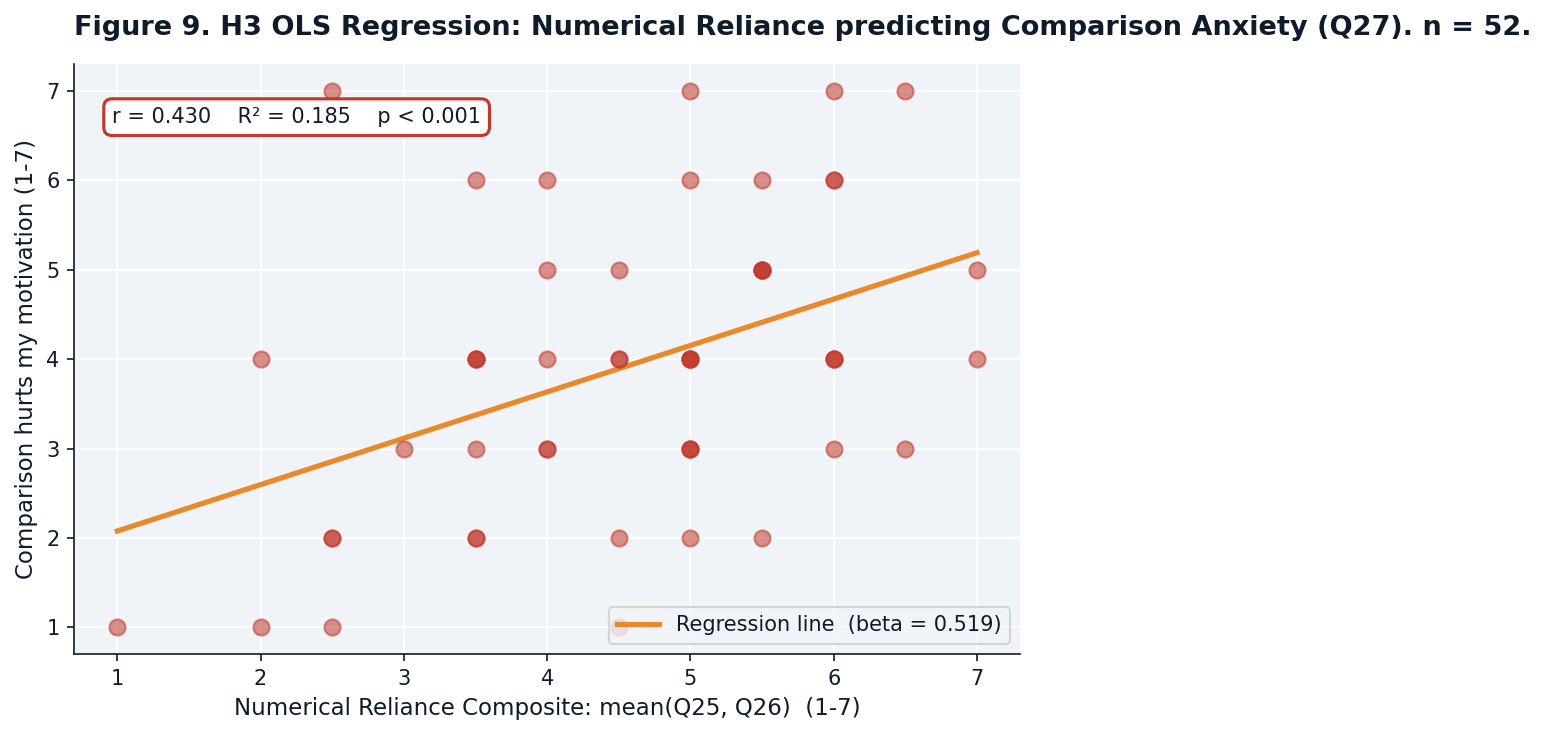

Figure 9 saved.


In [15]:
# Figure 9: H3 OLS Regression — Numerical Reliance vs Comparison Anxiety
d = users[['H3_composite', COL['comparison']]].dropna()
slope, intercept, r, p, se = stats.linregress(d['H3_composite'], d[COL['comparison']])
x_line = np.linspace(d['H3_composite'].min(), d['H3_composite'].max(), 200)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(d['H3_composite'], d[COL['comparison']], color=RED, alpha=0.55, s=60, zorder=3)
ax.plot(x_line, slope * x_line + intercept, color=ORANGE, linewidth=2.5,
        label=f'Regression line  (beta = {slope:.3f})')
ax.set_xlabel('Numerical Reliance Composite: mean(Q25, Q26)  (1-7)')
ax.set_ylabel('Comparison hurts my motivation (1-7)')
sport_title(ax, 'Figure 9. H3 OLS Regression: Numerical Reliance predicting Comparison Anxiety (Q27). n = 52.')
ax.legend(fontsize=10)
ax.text(0.04, 0.90, f'r = {r:.3f}    R² = {r**2:.3f}    p < 0.001',
        transform=ax.transAxes, fontsize=10, color=NAVY,
        bbox=dict(boxstyle='round,pad=0.4', facecolor=WHITE, edgecolor=RED, linewidth=1.5))
plt.tight_layout()
plt.savefig('Figure_9_H3_Regression.png', bbox_inches='tight')
plt.show()
print('Figure 9 saved.')


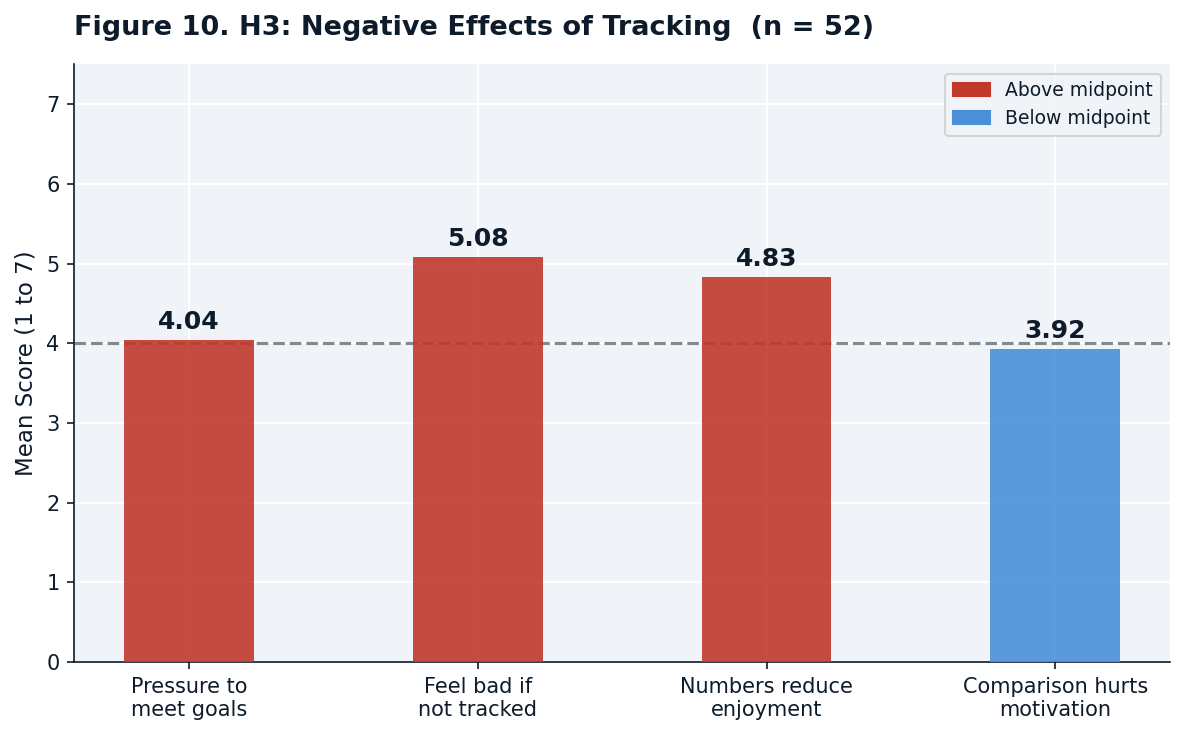

Figure 10 saved.


In [16]:
# Figure 10: H3 Negative Effects Mean Scores
fig, ax = plt.subplots(figsize=(8, 5))
neg = {
    'Pressure to\nmeet goals':       users[COL['pressure']].mean(),
    'Feel bad if\nnot tracked':       users[COL['guilt']].mean(),
    'Numbers reduce\nenjoyment':      users[COL['numbers']].mean(),
    'Comparison hurts\nmotivation':   users[COL['comparison']].mean(),
}
bar_colors_neg = [RED if v > 4 else LIGHTBLUE for v in neg.values()]
bars = ax.bar(neg.keys(), neg.values(), color=bar_colors_neg, width=0.45, zorder=3, alpha=0.9)
ax.axhline(y=4, color=MIDGRAY, linestyle='--', linewidth=1.5)
for bar, val in zip(bars, neg.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.08,
            f'{val:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold', color=NAVY)
ax.set_ylabel('Mean Score (1 to 7)')
ax.set_ylim(0, 7.5)
sport_title(ax, 'Figure 10. H3: Negative Effects of Tracking  (n = 52)')
legend_patches = [
    mpatches.Patch(color=RED,       label='Above midpoint'),
    mpatches.Patch(color=LIGHTBLUE, label='Below midpoint'),
]
ax.legend(handles=legend_patches, fontsize=9)
plt.tight_layout()
plt.savefig('Figure_10_H3_Negative_Effects.png', bbox_inches='tight')
plt.show()
print('Figure 10 saved.')


# STEP 8: Non-User Analysis (Figure 11)

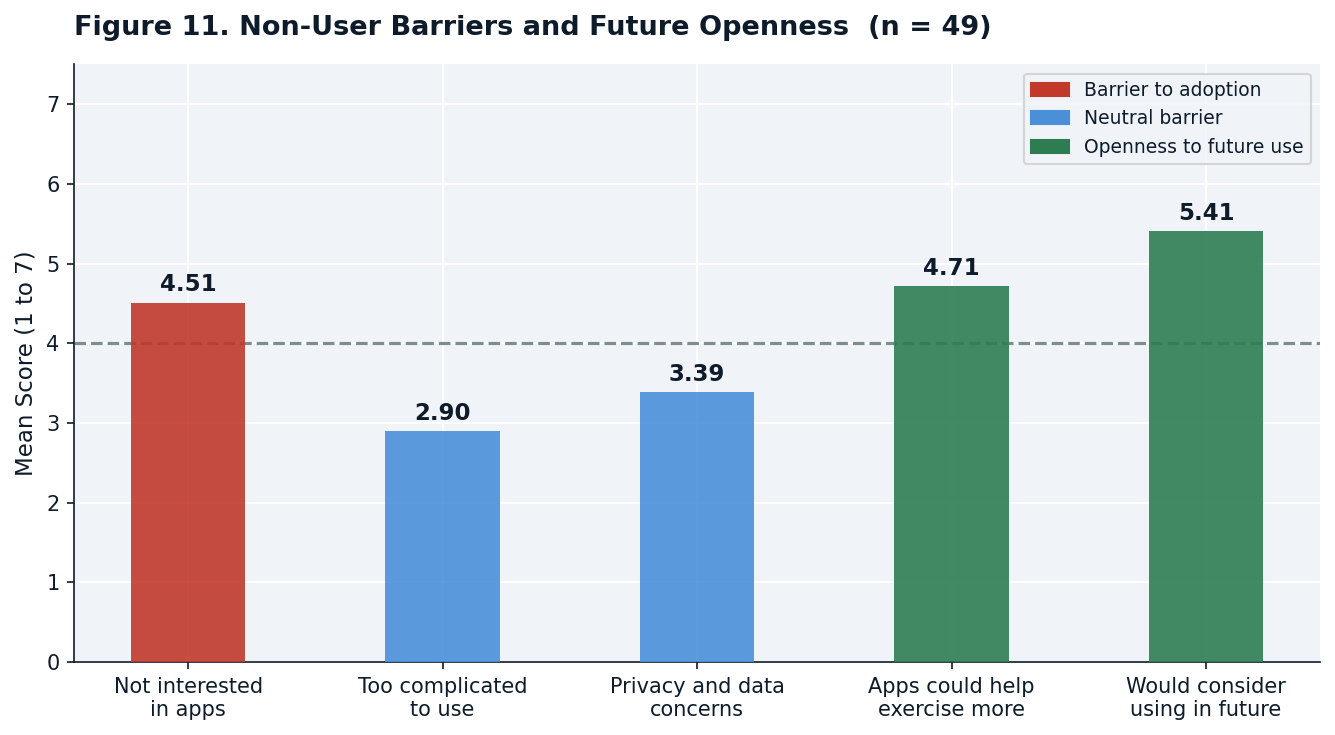

Figure 11 saved.


In [17]:
# Figure 11: Non-User Barriers and Openness
fig, ax = plt.subplots(figsize=(9, 5))
nu = {
    'Not interested\nin apps':            non_users[COL['nu_interest']].mean(),
    'Too complicated\nto use':            non_users[COL['nu_complex']].mean(),
    'Privacy and data\nconcerns':         non_users[COL['nu_privacy']].mean(),
    'Apps could help\nexercise more':     non_users[COL['nu_help']].mean(),
    'Would consider\nusing in future':    non_users[COL['nu_future']].mean(),
}
bar_colors_nu = [RED, LIGHTBLUE, LIGHTBLUE, GREEN, GREEN]
bars = ax.bar(nu.keys(), nu.values(), color=bar_colors_nu, width=0.45, zorder=3, alpha=0.9)
ax.axhline(y=4, color=MIDGRAY, linestyle='--', linewidth=1.5)
for bar, val in zip(bars, nu.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.08,
            f'{val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold', color=NAVY)
ax.set_ylabel('Mean Score (1 to 7)')
ax.set_ylim(0, 7.5)
sport_title(ax, 'Figure 11. Non-User Barriers and Future Openness  (n = 49)')
legend_patches = [
    mpatches.Patch(color=RED,       label='Barrier to adoption'),
    mpatches.Patch(color=LIGHTBLUE, label='Neutral barrier'),
    mpatches.Patch(color=GREEN,     label='Openness to future use'),
]
ax.legend(handles=legend_patches, fontsize=9)
plt.tight_layout()
plt.savefig('Figure_11_NonUser_Analysis.png', bbox_inches='tight')
plt.show()
print('Figure 11 saved.')


# STEP 9: Correlation Heatmap (Figure 12)

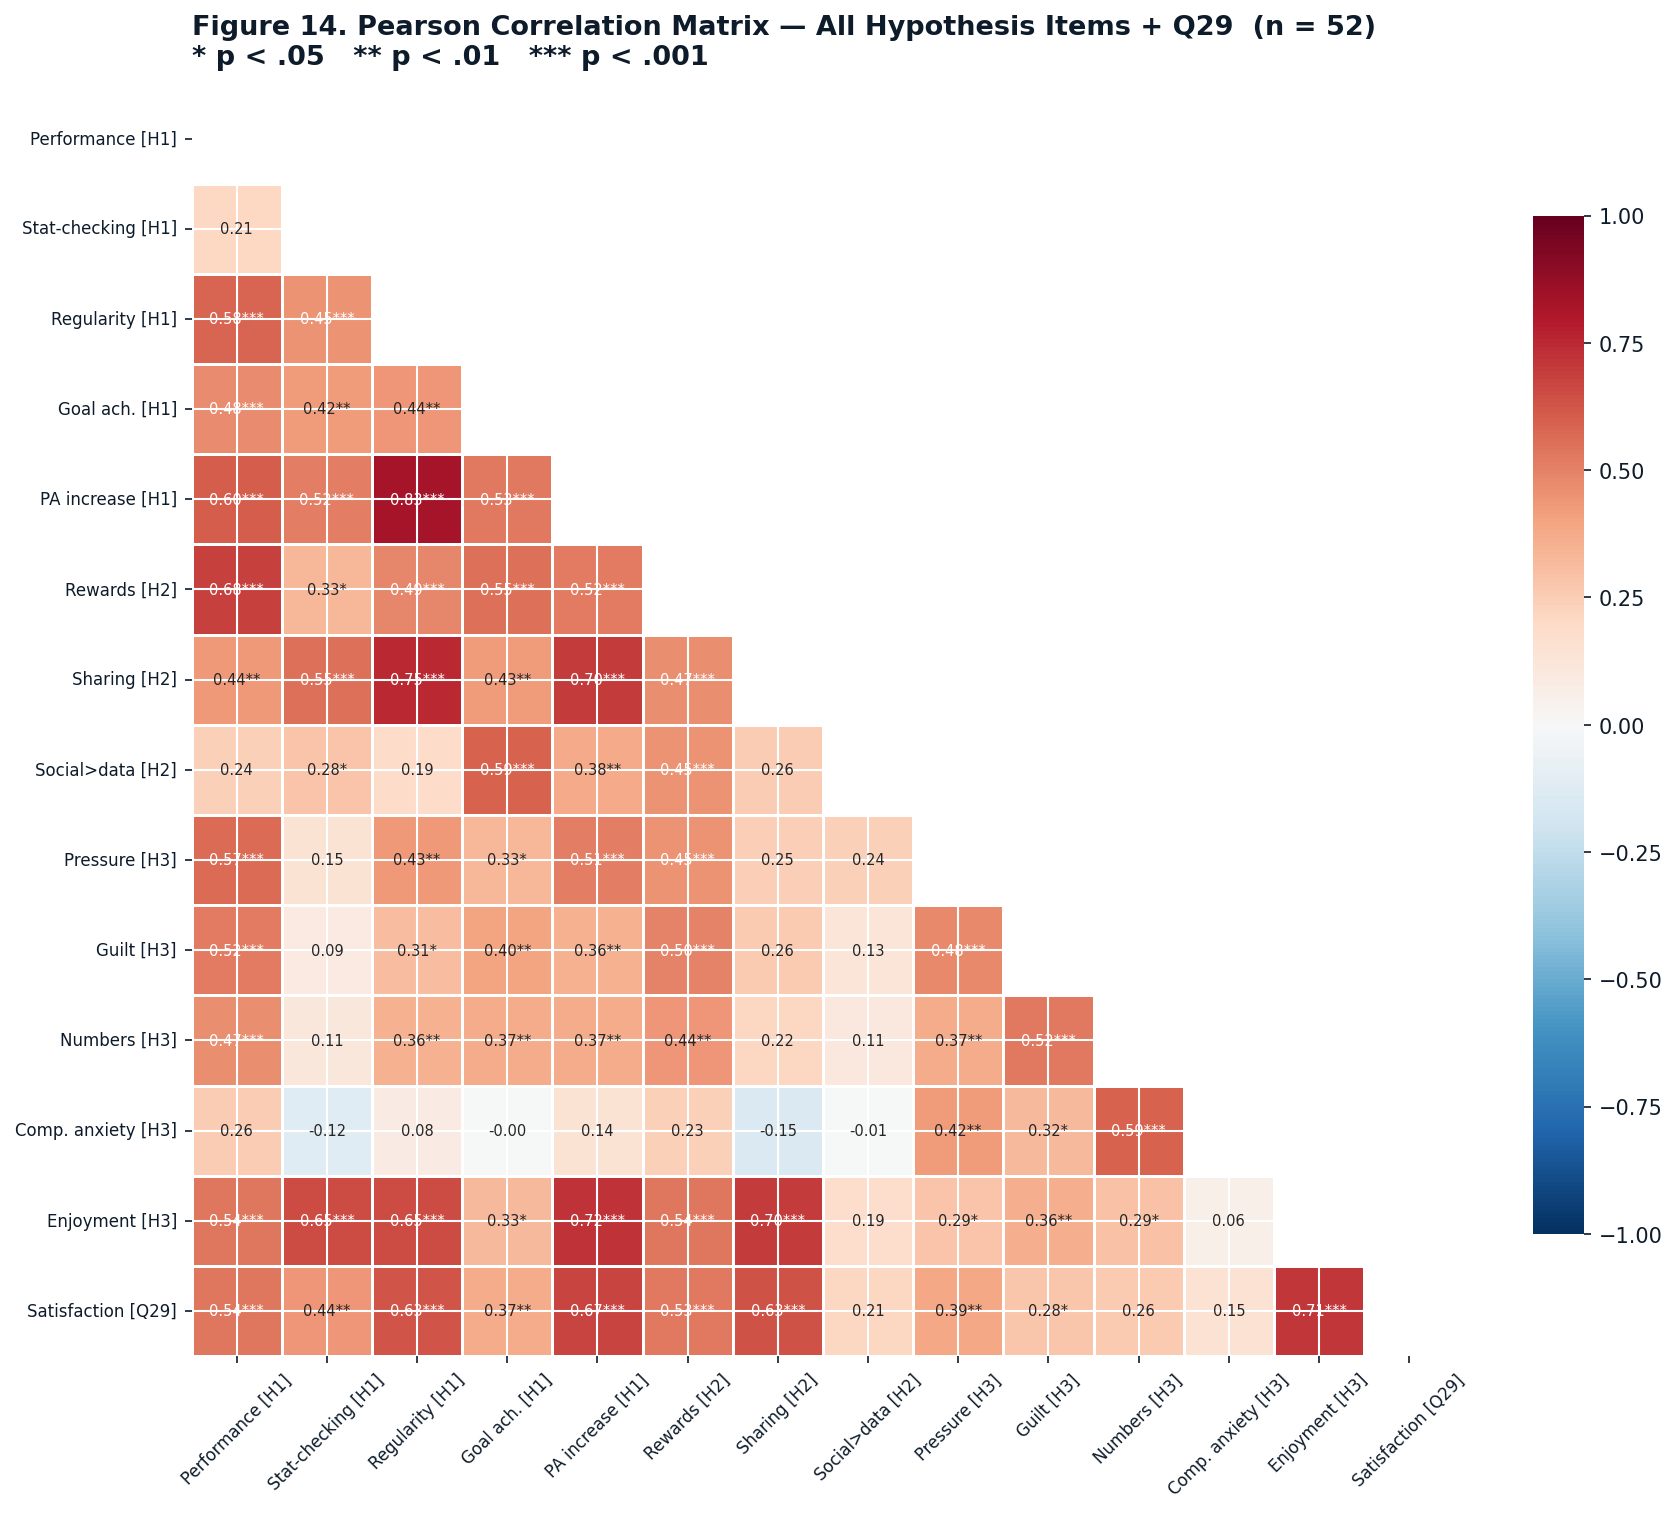

Figure 14 saved.


In [18]:
# ── FIGURE 14: Correlation Heatmap with Significance Stars ──────────────
# Replace your existing Figure 12 heatmap cell with this code.
# Uses your existing variables (users, COL, sport_title, colour constants).

from scipy import stats as _stats

# ── 1. Define the 14 columns (same order as your existing corr_cols) ────
corr_cols = [
    COL['performance'], COL['stats'],     COL['regularity'],
    COL['goal_ach'],    COL['pa_increase'],
    COL['rewards'],     COL['sharing'],   COL['social_vs'],
    COL['pressure'],    COL['guilt'],     COL['numbers'],
    COL['comparison'],  COL['enjoy'],     COL['satisfaction'],
]

corr_labels = [
    'Performance [H1]', 'Stat-checking [H1]', 'Regularity [H1]',
    'Goal ach. [H1]',   'PA increase [H1]',
    'Rewards [H2]',     'Sharing [H2]',       'Social>data [H2]',
    'Pressure [H3]',    'Guilt [H3]',         'Numbers [H3]',
    'Comp. anxiety [H3]', 'Enjoyment [H3]',   'Satisfaction [Q29]',
]

# ── 2. Compute correlation matrix ───────────────────────────────────────
corr_data         = users[corr_cols].dropna().copy()
corr_data.columns = corr_labels
corr_matrix       = corr_data.corr()
n_obs             = len(corr_data)          # should be 52

# ── 3. Build annotation matrix: value + significance stars ──────────────
def _sig_star(r_val, n):
    if abs(r_val) >= 1.0:
        return ''
    t = r_val * np.sqrt(n - 2) / np.sqrt(max(1 - r_val**2, 1e-10))
    p = 2 * (1 - _stats.t.cdf(abs(t), df=n - 2))
    if   p < 0.001: return '***'
    elif p < 0.01:  return '**'
    elif p < 0.05:  return '*'
    return ''

n_vars = len(corr_labels)
annot  = np.empty((n_vars, n_vars), dtype=object)

for i in range(n_vars):
    for j in range(n_vars):
        r_val = corr_matrix.iloc[i, j]
        if i == j:
            annot[i, j] = '1.00'
        elif i > j:                          # lower triangle only
            star          = _sig_star(r_val, n_obs)
            annot[i, j]   = f'{r_val:.2f}{star}'
        else:
            annot[i, j] = ''                 # upper triangle stays blank

# ── 4. Mask upper triangle ───────────────────────────────────────────────
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# ── 5. Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor(WHITE)
ax.set_facecolor(WHITE)

sns.heatmap(
    corr_matrix, mask=mask,
    annot=annot, fmt='',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, linecolor=WHITE,
    annot_kws={'size': 7}, ax=ax,
    cbar_kws={'shrink': 0.8}
)

sport_title(
    ax,
    'Figure 14. Pearson Correlation Matrix — All Hypothesis Items + Q29  (n = 52)\n'
    '* p < .05   ** p < .01   *** p < .001'
)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.tight_layout()
plt.savefig('Figure_14_Correlation_Heatmap.png', bbox_inches='tight')
plt.show()
print('Figure 14 saved.')

# STEP 10: Q29 Overall Satisfaction Correlations

In [19]:
# Q29 correlations with all three composites
print('Q29 OVERALL SATISFACTION CORRELATIONS')
print('=' * 50)
for label, col in [
    ('H1 Data Feedback Composite',     'H1_composite'),
    ('H2 Social Motivation Composite',  'H2_composite'),
    ('H3 Numerical Reliance Composite', 'H3_composite'),
]:
    d = users[[col, COL['satisfaction']]].dropna()
    r, p = stats.pearsonr(d[col], d[COL['satisfaction']])
    print(f'  Q29 x {label}: r = {r:.3f}, p = {p:.3f}')


Q29 OVERALL SATISFACTION CORRELATIONS
  Q29 x H1 Data Feedback Composite: r = 0.629, p = 0.000
  Q29 x H2 Social Motivation Composite: r = 0.632, p = 0.000
  Q29 x H3 Numerical Reliance Composite: r = 0.384, p = 0.005


# STEP 11: Full Statistical Summary

In [20]:
print('\n' + '='*60)
print('STATISTICAL SUMMARY')
print('='*60)
print(f'\nTotal: {len(df)}  |  Users: {len(users)}  |  Non-users: {len(non_users)}')

r_h1, p_h1 = stats.pearsonr(users[COL['performance']].dropna(), users[COL['stats']].dropna())
print('\n--- H1 ---')
print(f'  Inter-item r (Q15 x Q21): r = {r_h1:.3f}, p = {p_h1:.3f}')
print(f'  Spearman-Brown: {(2*r_h1)/(1+r_h1):.3f}')
for cx, cy, lbl in [
    (COL['performance'], COL['goal_ach'],    'Performance x Goal achievement'),
    (COL['stats'],       COL['goal_ach'],    'Stat-checking x Goal achievement'),
    (COL['regularity'],  COL['pa_increase'], 'Regularity x PA increase'),
    ('H1_composite',     COL['goal_ach'],    'H1 composite x Goal achievement'),
    ('H1_composite',     COL['pa_increase'], 'H1 composite x PA increase'),
    ('H1_composite',     COL['regularity'],  'H1 composite x Regularity (Q20)'),
]:
    c = users[[cx, cy]].dropna()
    r, p = stats.pearsonr(c.iloc[:,0], c.iloc[:,1])
    print(f'  {lbl}: r = {r:.3f}, p = {p:.3f}')

print('\n--- H2 ---')
for cx, cy, lbl in [
    (COL['sharing'],     COL['engagement'], 'Sharing x Engagement'),
    (COL['rewards'],     COL['engagement'], 'Rewards x Engagement'),
    (COL['competition'], COL['engagement'], 'Competition x Engagement'),
]:
    c = users[[cx, cy]].dropna()
    r, p = stats.pearsonr(c.iloc[:,0], c.iloc[:,1])
    print(f'  {lbl}: r = {r:.3f}, p = {p:.3f}')
soc = users['H2_composite'].dropna()
dat = users[COL['performance']].dropna()
t, pt = stats.ttest_rel(soc, dat[:len(soc)])
print(f'  Paired t-test (social vs data): t = {t:.3f}, p = {pt:.3f}')

print('\n--- H3 (clean composite Q25+Q26) ---')
for dv_label, dv_col in [
    ('Numerical Reliance x Enjoyment (Q16)',             COL['enjoy']),
    ('Numerical Reliance x Comparison anxiety (Q27)',    COL['comparison']),
    ('Numerical Reliance x Numbers reduce enjoy (Q28)',  COL['numbers']),
]:
    d = users[['H3_composite', dv_col]].dropna()
    r, p = stats.pearsonr(d['H3_composite'], d[dv_col])
    print(f'  {dv_label}: r = {r:.3f}, p = {p:.3f}')

print('\n--- Q29 ---')
for label, col in [
    ('H1 composite', 'H1_composite'),
    ('H2 composite', 'H2_composite'),
    ('H3 composite', 'H3_composite'),
]:
    d = users[[col, COL['satisfaction']]].dropna()
    r, p = stats.pearsonr(d[col], d[COL['satisfaction']])
    print(f'  Q29 x {label}: r = {r:.3f}, p = {p:.3f}')

print('\nAll 12 figures saved successfully.')



STATISTICAL SUMMARY

Total: 101  |  Users: 52  |  Non-users: 49

--- H1 ---
  Inter-item r (Q15 x Q21): r = 0.210, p = 0.134
  Spearman-Brown: 0.348
  Performance x Goal achievement: r = 0.476, p = 0.000
  Stat-checking x Goal achievement: r = 0.423, p = 0.002
  Regularity x PA increase: r = 0.834, p = 0.000
  H1 composite x Goal achievement: r = 0.570, p = 0.000
  H1 composite x PA increase: r = 0.714, p = 0.000
  H1 composite x Regularity (Q20): r = 0.665, p = 0.000

--- H2 ---
  Sharing x Engagement: r = 0.568, p = 0.000
  Rewards x Engagement: r = 0.288, p = 0.039
  Competition x Engagement: r = 0.270, p = 0.053
  Paired t-test (social vs data): t = 0.316, p = 0.753

--- H3 (clean composite Q25+Q26) ---
  Numerical Reliance x Enjoyment (Q16): r = 0.379, p = 0.006
  Numerical Reliance x Comparison anxiety (Q27): r = 0.430, p = 0.001
  Numerical Reliance x Numbers reduce enjoy (Q28): r = 0.523, p = 0.000

--- Q29 ---
  Q29 x H1 composite: r = 0.629, p = 0.000
  Q29 x H2 composite: r

# STEP 12: K-means Clustering

In [21]:
# Define cluster input variables
cluster_inputs = [
    COL['performance'],   # Q15
    COL['rewards'],       # Q17
    COL['competition'],   # Q18
    COL['sharing'],       # Q19
    COL['stats'],         # Q21
    COL['pressure'],      # Q25
    COL['guilt'],         # Q26
    COL['numbers'],       # Q28
]

# Export user subset for clustering tool
cluster_export = users[cluster_inputs].dropna().copy()
cluster_export.columns = ['Q15_Performance', 'Q17_Rewards', 'Q18_Competition',
                           'Q19_Sharing', 'Q21_Stats', 'Q25_Pressure',
                           'Q26_Guilt', 'Q28_Numbers']
cluster_export.to_csv('users_clustering.csv', index=False)
print(f'Exported {len(cluster_export)} rows')
print(cluster_export.head())

Exported 52 rows
    Q15_Performance  Q17_Rewards  Q18_Competition  Q19_Sharing  Q21_Stats  \
0               7.0          7.0              7.0          7.0        7.0   
2               7.0          6.0              2.0          4.0        7.0   
3               1.0          1.0              6.0          7.0        7.0   
11              7.0          4.0              4.0          7.0        7.0   
13              3.0          5.0              2.0          2.0        4.0   

    Q25_Pressure  Q26_Guilt  Q28_Numbers  
0            5.0        7.0          4.0  
2            5.0        5.0          4.0  
3            1.0        1.0          1.0  
11           4.0        6.0          6.0  
13           2.0        5.0          6.0  


In [22]:
# Add cluster labels from k=3 solution
# Manually assign based on tool output order
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cluster_data = users[cluster_inputs].dropna().copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_data)

km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_data['cluster'] = km3.fit_predict(X_scaled)

# Merge back to users
users_c = users.loc[cluster_data.index].copy()
users_c['cluster'] = cluster_data['cluster']

# Profile variables
profile_vars = {
    'Q13 Engagement':         COL['engagement'],
    'Q16 Enjoyment':          COL['enjoy'],
    'Q22 Goal achievement':   COL['goal_ach'],
    'Q23 PA increase':        COL['pa_increase'],
    'Q27 Comparison anxiety': COL['comparison'],
    'Q29 Satisfaction':       COL['satisfaction'],
}

print('PROFILE VARIABLES BY CLUSTER')
print('=' * 50)
for label, col in profile_vars.items():
    row = users_c.groupby('cluster')[col].mean().round(2)
    print(f'{label}: {row.to_dict()}')

print('\nCluster sizes:')
print(users_c['cluster'].value_counts().sort_index())

PROFILE VARIABLES BY CLUSTER
Q13 Engagement: {0: 6.08, 1: 4.5, 2: 5.72}
Q16 Enjoyment: {0: 6.67, 1: 5.0, 2: 6.06}
Q22 Goal achievement: {0: 6.71, 1: 4.3, 2: 5.94}
Q23 PA increase: {0: 6.58, 1: 3.8, 2: 5.67}
Q27 Comparison anxiety: {0: 4.25, 1: 3.5, 2: 3.72}
Q29 Satisfaction: {0: 6.75, 1: 5.0, 2: 6.33}

Cluster sizes:
cluster
0    24
1    10
2    18
Name: count, dtype: int64


In [25]:
# ── TABLE 4: CLUSTER PROFILES ─────────────────────────────────
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Re-run k=3 clustering
cluster_data = users[cluster_inputs].dropna().copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_data)
km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_data['cluster'] = km3.fit_predict(X_scaled)
users_c = users.loc[cluster_data.index].copy()
users_c['cluster'] = cluster_data['cluster']

# Rename clusters to match thesis labels
cluster_names = {0: 'A: Motivated Achievers (n=24)',
                 1: 'C: Light Users (n=10)',
                 2: 'B: Moderate Users (n=18)'}
users_c['cluster_label'] = users_c['cluster'].map(cluster_names)

# Define all rows for the table
input_rows = {
    'Q15 Performance motivation':    COL['performance'],
    'Q17 Rewards motivation':        COL['rewards'],
    'Q18 Competition motivation':    COL['competition'],
    'Q19 Sharing motivation':        COL['sharing'],
    'Q21 Stats-checking':            COL['stats'],
    'Q25 Goal pressure':             COL['pressure'],
    'Q26 Guilt when not tracking':   COL['guilt'],
    'Q28 Numbers reduce enjoyment':  COL['numbers'],
}

profile_rows = {
    'Q13 App engagement frequency':  COL['engagement'],
    'Q16 Exercise enjoyment':        COL['enjoy'],
    'Q22 Goal achievement':          COL['goal_ach'],
    'Q23 PA increase':               COL['pa_increase'],
    'Q27 Comparison anxiety':        COL['comparison'],
    'Q29 Overall satisfaction':      COL['satisfaction'],
}

# Column order
col_order = [
    'A: Motivated Achievers (n=24)',
    'B: Moderate Users (n=18)',
    'C: Light Users (n=10)',
]

print('=' * 85)
print('TABLE 4 — CLUSTER PROFILES: INPUT AND PROFILE VARIABLE MEANS (App Users, n = 52)')
print('=' * 85)
print(f'{"Variable":<35} {"Cluster A":>12} {"Cluster B":>12} {"Cluster C":>12}')
print(f'{"(Input variables)":<35} {"Mot. Achievers":>12} {"Mod. Users":>12} {"Light Users":>12}')
print(f'{"":35} {"(n=24)":>12} {"(n=18)":>12} {"(n=10)":>12}')
print('-' * 85)

print('-- INPUT VARIABLES (used in clustering) --')
for label, col in input_rows.items():
    means = users_c.groupby('cluster_label')[col].mean()
    a = means.get('A: Motivated Achievers (n=24)', np.nan)
    b = means.get('B: Moderate Users (n=18)', np.nan)
    c = means.get('C: Light Users (n=10)', np.nan)
    print(f'{label:<35} {a:>12.2f} {b:>12.2f} {c:>12.2f}')

print()
print('-- PROFILE VARIABLES (not used in clustering) --')
for label, col in profile_rows.items():
    means = users_c.groupby('cluster_label')[col].mean()
    a = means.get('A: Motivated Achievers (n=24)', np.nan)
    b = means.get('B: Moderate Users (n=18)', np.nan)
    c = means.get('C: Light Users (n=10)', np.nan)
    print(f'{label:<35} {a:>12.2f} {b:>12.2f} {c:>12.2f}')

print('=' * 85)
print('Note. All items scored on a 1–7 scale. Input variables were standardised before')
print('clustering. Profile variables were not used as clustering inputs.')

TABLE 4 — CLUSTER PROFILES: INPUT AND PROFILE VARIABLE MEANS (App Users, n = 52)
Variable                               Cluster A    Cluster B    Cluster C
(Input variables)                   Mot. Achievers   Mod. Users  Light Users
                                          (n=24)       (n=18)       (n=10)
-------------------------------------------------------------------------------------
-- INPUT VARIABLES (used in clustering) --
Q15 Performance motivation                  6.42         5.39         3.30
Q17 Rewards motivation                      6.50         5.61         3.20
Q18 Competition motivation                  6.17         5.11         3.10
Q19 Sharing motivation                      6.46         6.11         3.60
Q21 Stats-checking                          6.67         6.44         5.60
Q25 Goal pressure                           4.75         3.72         2.90
Q26 Guilt when not tracking                 6.25         4.28         3.70
Q28 Numbers reduce enjoyment          

# STEP 13: Subgroup Analysis

In [29]:
from scipy.stats import ttest_ind, chi2_contingency

# Add activity to COL
COL['activity'] = 'What type of physical activity do you practice most frequently?'

print('=' * 70)
print('SUBGROUP ANALYSES — FIXED')
print('=' * 70)

# ── 1. GENDER × COMPOSITES ───────────────────────────────────
print('\n--- 1. GENDER GROUP COMPARISONS (Male vs Female) ---')
male   = users[users[COL['gender']] == 'Male']
female = users[users[COL['gender']] == 'Female']

for label, col in [
    ('H1 Data Feedback Composite',     'H1_composite'),
    ('H2 Social Motivation Composite', 'H2_composite'),
    ('H3 Numerical Reliance Composite','H3_composite'),
]:
    m = male[col].dropna()
    f = female[col].dropna()
    t, p = ttest_ind(m, f)
    print(f'{label}:')
    print(f'  Male M={m.mean():.2f} (n={len(m)}) | Female M={f.mean():.2f} (n={len(f)}) | t={t:.3f}, p={p:.3f}')

# ── 2. AGE GROUP × COMPOSITES ────────────────────────────────
print('\n--- 2. AGE GROUP COMPARISONS (18-24 vs 25+) ---')
young = users[users[COL['age']] == '18-24']
older = users[users[COL['age']] != '18-24']

for label, col in [
    ('H1 Data Feedback Composite',     'H1_composite'),
    ('H2 Social Motivation Composite', 'H2_composite'),
    ('H3 Numerical Reliance Composite','H3_composite'),
]:
    y = young[col].dropna()
    o = older[col].dropna()
    t, p = ttest_ind(y, o)
    print(f'{label}:')
    print(f'  18-24 M={y.mean():.2f} (n={len(y)}) | 25+ M={o.mean():.2f} (n={len(o)}) | t={t:.3f}, p={p:.3f}')

# ── 3. USAGE FREQUENCY × COMPOSITES ─────────────────────────
print('\n--- 3. USAGE FREQUENCY (High ≥6 vs Low ≤4) ---')
high_freq = users[users[COL['engagement']] >= 6]
low_freq  = users[users[COL['engagement']] <= 4]

for label, col in [
    ('H1 Data Feedback Composite',     'H1_composite'),
    ('H2 Social Motivation Composite', 'H2_composite'),
    ('H3 Numerical Reliance Composite','H3_composite'),
]:
    h = high_freq[col].dropna()
    l = low_freq[col].dropna()
    t, p = ttest_ind(h, l)
    print(f'{label}:')
    print(f'  High M={h.mean():.2f} (n={len(h)}) | Low M={l.mean():.2f} (n={len(l)}) | t={t:.3f}, p={p:.3f}')

# ── 4. ACTIVITY TYPE × USER/NON-USER CROSSTAB ────────────────
print('\n--- 4. ACTIVITY TYPE × USER/NON-USER STATUS ---')
df['is_user'] = df[COL['app_use']].apply(lambda x: 'User' if x == 'Yes' else 'Non-User')

def simplify_activity(val):
    val = str(val).lower()
    if 'team' in val:
        return 'Team Sports'
    elif 'running' in val:
        return 'Running'
    elif 'gym' in val or 'weight' in val:
        return 'Gym / Weight Training'
    elif 'cycling' in val or 'swimming' in val:
        return 'Cycling / Swimming'
    else:
        return 'Other'

df['activity_clean'] = df[COL['activity']].apply(simplify_activity)
crosstab_clean = pd.crosstab(df['activity_clean'], df['is_user'])
print(crosstab_clean)

print('\nRow percentages (% who are Users within each activity type):')
row_pct = crosstab_clean.div(crosstab_clean.sum(axis=1), axis=0).round(2) * 100
print(row_pct)

chi2, p_chi, dof, expected = chi2_contingency(crosstab_clean)
print(f'\nChi-square = {chi2:.3f}, df = {dof}, p = {p_chi:.3f}')

# ── TABLE 5 ───────────────────────────────────────────────────
print('\n' + '=' * 55)
print('Table 5 — Activity type × App user status (n = 101)')
print('=' * 55)
print(f'{"Activity Type":<25} {"Non-Users":>10} {"Users":>7} {"% Users":>9}')
print('-' * 55)
for activity in crosstab_clean.index:
    nu = crosstab_clean.loc[activity, 'Non-User']
    u  = crosstab_clean.loc[activity, 'User']
    pct = round(u / (nu + u) * 100)
    print(f'{activity:<25} {nu:>10} {u:>7} {pct:>8}%')
print('-' * 55)
print('Chi-square = 24.596, df = 4, p < .001')

SUBGROUP ANALYSES — FIXED

--- 1. GENDER GROUP COMPARISONS (Male vs Female) ---
H1 Data Feedback Composite:
  Male M=6.12 (n=24) | Female M=5.75 (n=28) | t=1.423, p=0.161
H2 Social Motivation Composite:
  Male M=5.97 (n=24) | Female M=5.13 (n=28) | t=2.314, p=0.025
H3 Numerical Reliance Composite:
  Male M=4.71 (n=24) | Female M=4.43 (n=28) | t=0.730, p=0.469

--- 2. AGE GROUP COMPARISONS (18-24 vs 25+) ---
H1 Data Feedback Composite:
  18-24 M=6.11 (n=22) | 25+ M=5.78 (n=30) | t=1.236, p=0.222
H2 Social Motivation Composite:
  18-24 M=5.58 (n=22) | 25+ M=5.48 (n=30) | t=0.254, p=0.801
H3 Numerical Reliance Composite:
  18-24 M=4.82 (n=22) | 25+ M=4.37 (n=30) | t=1.178, p=0.244

--- 3. USAGE FREQUENCY (High ≥6 vs Low ≤4) ---
H1 Data Feedback Composite:
  High M=6.23 (n=30) | Low M=5.15 (n=10) | t=3.373, p=0.002
H2 Social Motivation Composite:
  High M=5.89 (n=30) | Low M=4.30 (n=10) | t=3.729, p=0.001
H3 Numerical Reliance Composite:
  High M=4.85 (n=30) | Low M=3.90 (n=10) | t=1.877, 

In [30]:
# ── CLEAN ACTIVITY CROSSTAB ───────────────────────────────────
def simplify_activity(val):
    val = str(val).lower()
    if 'team' in val:
        return 'Team Sports'
    elif 'running' in val:
        return 'Running'
    elif 'gym' in val or 'weight' in val:
        return 'Gym / Weight Training'
    elif 'cycling' in val or 'swimming' in val:
        return 'Cycling / Swimming'
    else:
        return 'Other'

df['activity_clean'] = df[COL['activity']].apply(simplify_activity)

print('\n--- 4. ACTIVITY TYPE × USER/NON-USER STATUS (simplified) ---')
crosstab_clean = pd.crosstab(df['activity_clean'], df['is_user'])
print(crosstab_clean)

# Add percentages
print('\nRow percentages (% who are Users within each activity type):')
row_pct = crosstab_clean.div(crosstab_clean.sum(axis=1), axis=0).round(2) * 100
print(row_pct)

chi2, p_chi, dof, expected = chi2_contingency(crosstab_clean)
print(f'\nChi-square = {chi2:.3f}, df = {dof}, p = {p_chi:.3f}')


--- 4. ACTIVITY TYPE × USER/NON-USER STATUS (simplified) ---
is_user                Non-User  User
activity_clean                       
Cycling / Swimming            1     1
Gym / Weight Training        12     9
Other                        16     3
Running                       4    25
Team Sports                  16    14

Row percentages (% who are Users within each activity type):
is_user                Non-User  User
activity_clean                       
Cycling / Swimming         50.0  50.0
Gym / Weight Training      57.0  43.0
Other                      84.0  16.0
Running                    14.0  86.0
Team Sports                53.0  47.0

Chi-square = 24.596, df = 4, p = 0.000


In [31]:
print('=' * 55)
print('TABLE 5 — ACTIVITY TYPE × APP USER STATUS (n = 101)')
print('=' * 55)
print(f'{"Activity Type":<25} {"Non-Users":>10} {"Users":>7} {"% Users":>9}')
print('-' * 55)
for activity in crosstab_clean.index:
    nu = crosstab_clean.loc[activity, 'Non-User']
    u  = crosstab_clean.loc[activity, 'User']
    pct = round(u / (nu + u) * 100)
    print(f'{activity:<25} {nu:>10} {u:>7} {pct:>8}%')
print('-' * 55)
print(f'Chi-square = 24.596, df = 4, p < .001')

TABLE 5 — ACTIVITY TYPE × APP USER STATUS (n = 101)
Activity Type              Non-Users   Users   % Users
-------------------------------------------------------
Cycling / Swimming                 1       1       50%
Gym / Weight Training             12       9       43%
Other                             16       3       16%
Running                            4      25       86%
Team Sports                       16      14       47%
-------------------------------------------------------
Chi-square = 24.596, df = 4, p < .001
